<p style="text-align:center"><a href="https://skills.network" target="_blank"><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"></a></p>


# **SpaceX Falcon 9 First Stage Landing Prediction**


## Hands-on Lab: Complete the EDA with Visualization


Estimated time needed: **70** minutes


In this lab, you will perform Exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`.


----


In [1]:
!pip install pandas numpy seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis


In [3]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


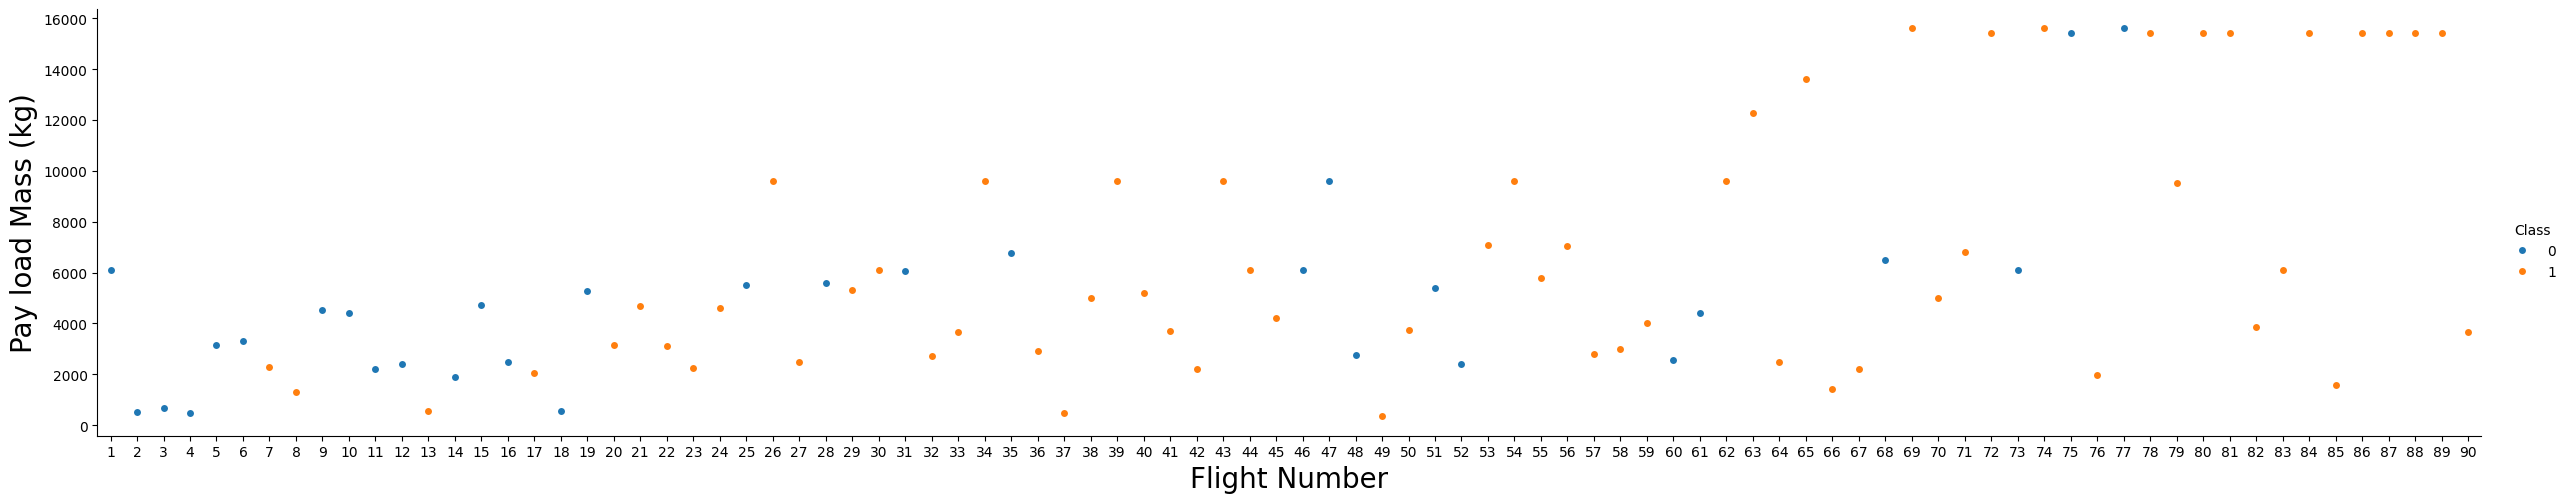

In [4]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Pay load Mass (kg)", fontsize=20)
plt.show()

### TASK 1: Visualize the relationship between Flight Number and Launch Site


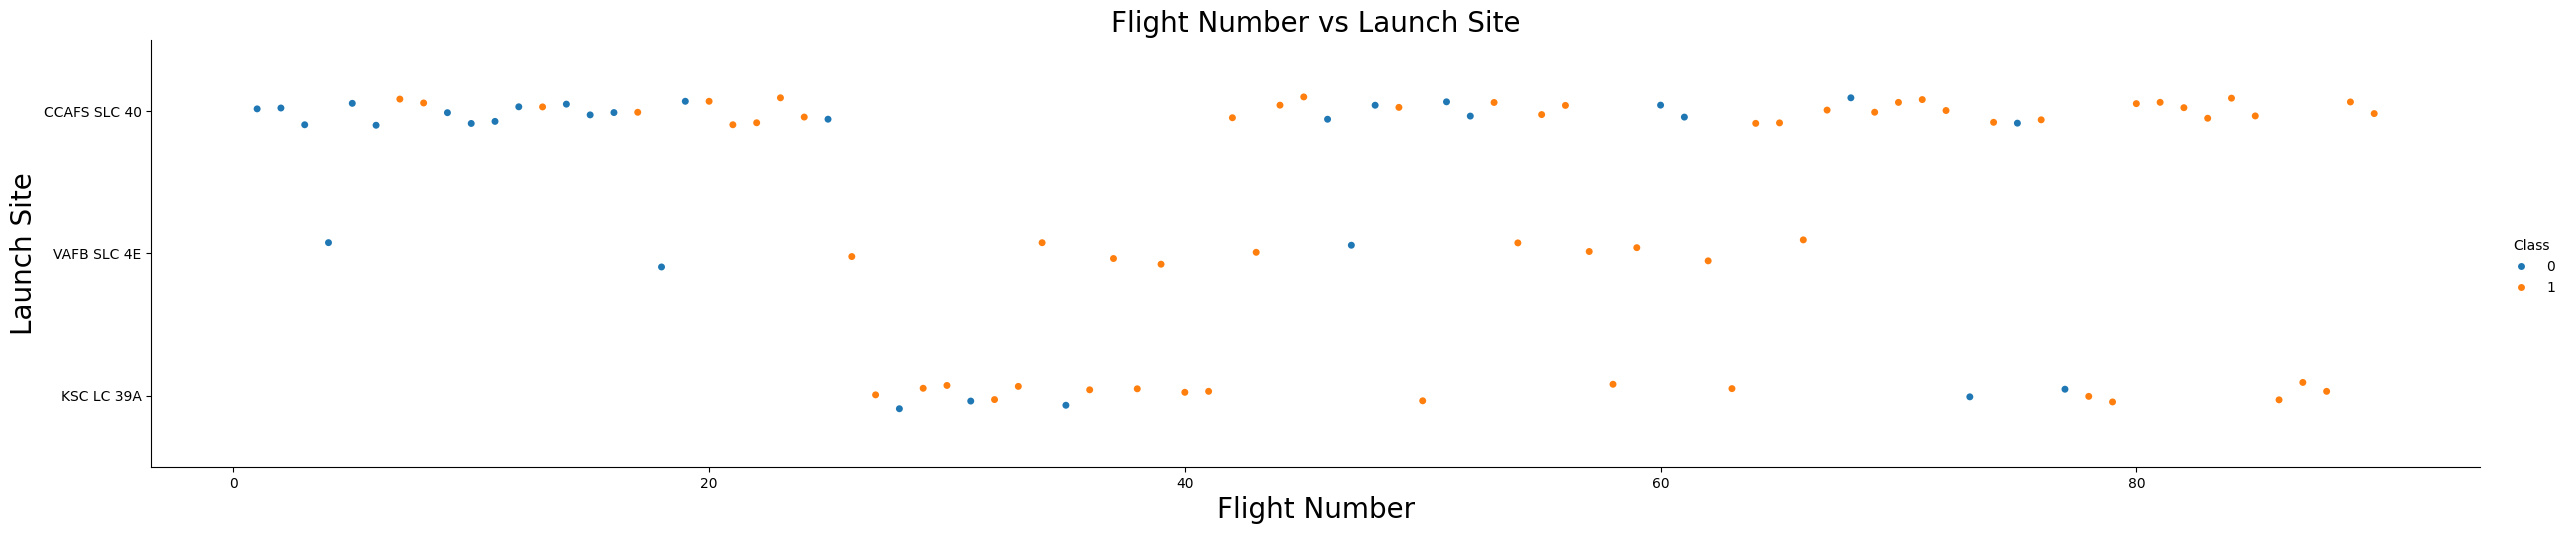

In [5]:
# Plot FlightNumber vs LaunchSite with hue = Class
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Flight Number vs Launch Site", fontsize=20)
plt.show()

### TASK 2: Visualize the relationship between Payload and Launch Site


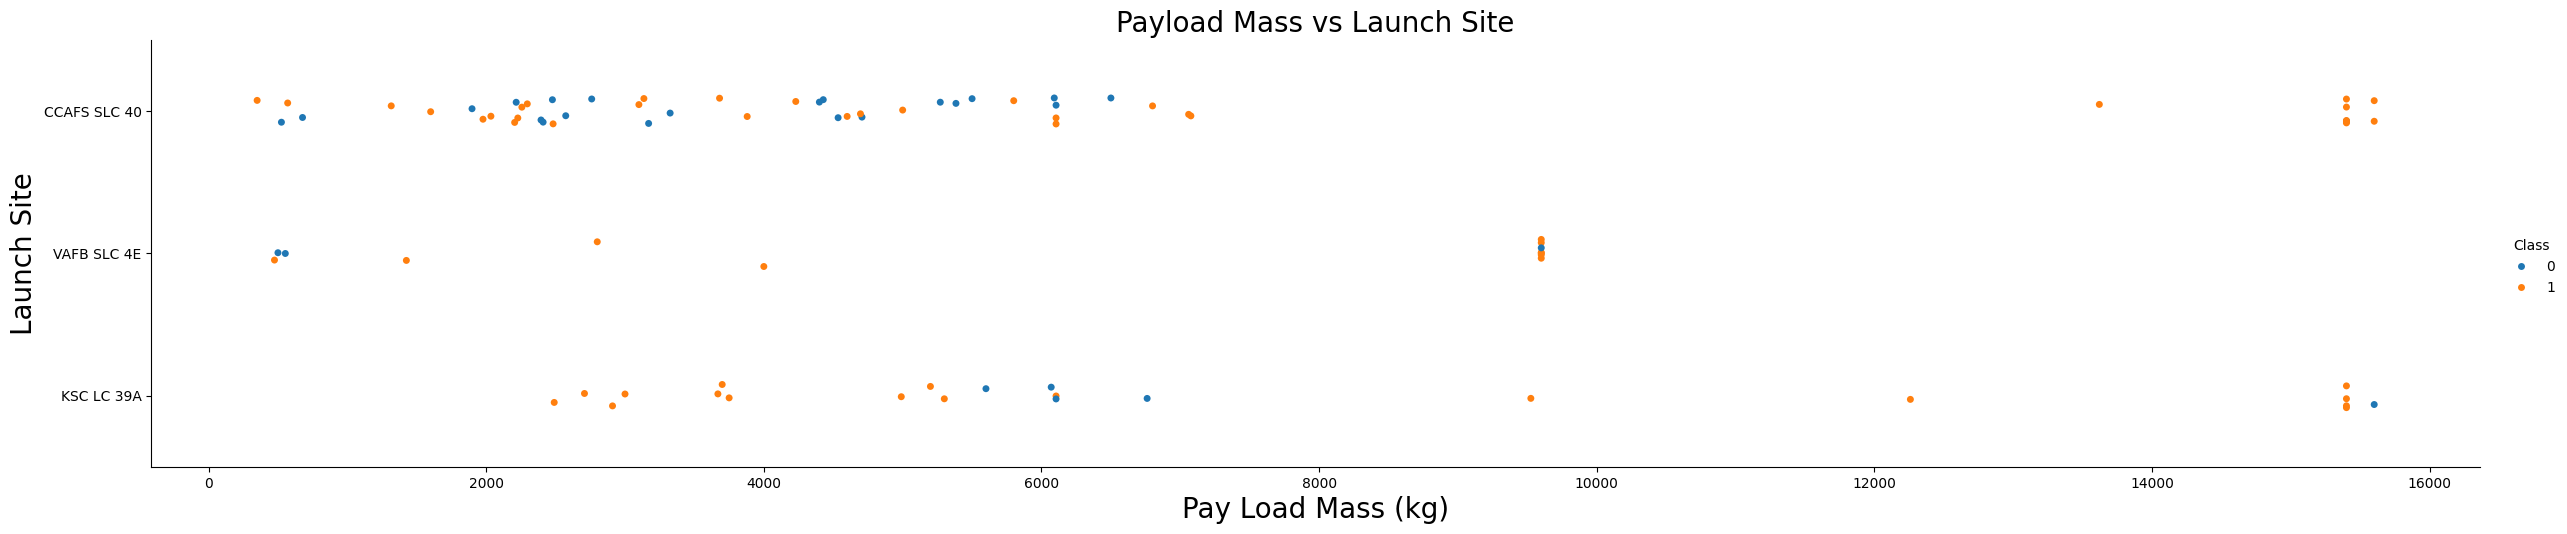

In [6]:
# Plot PayloadMass vs LaunchSite with hue = Class
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=5)
plt.xlabel("Pay Load Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Payload Mass vs Launch Site", fontsize=20)
plt.show()

### TASK 3: Visualize the relationship between success rate of each orbit type


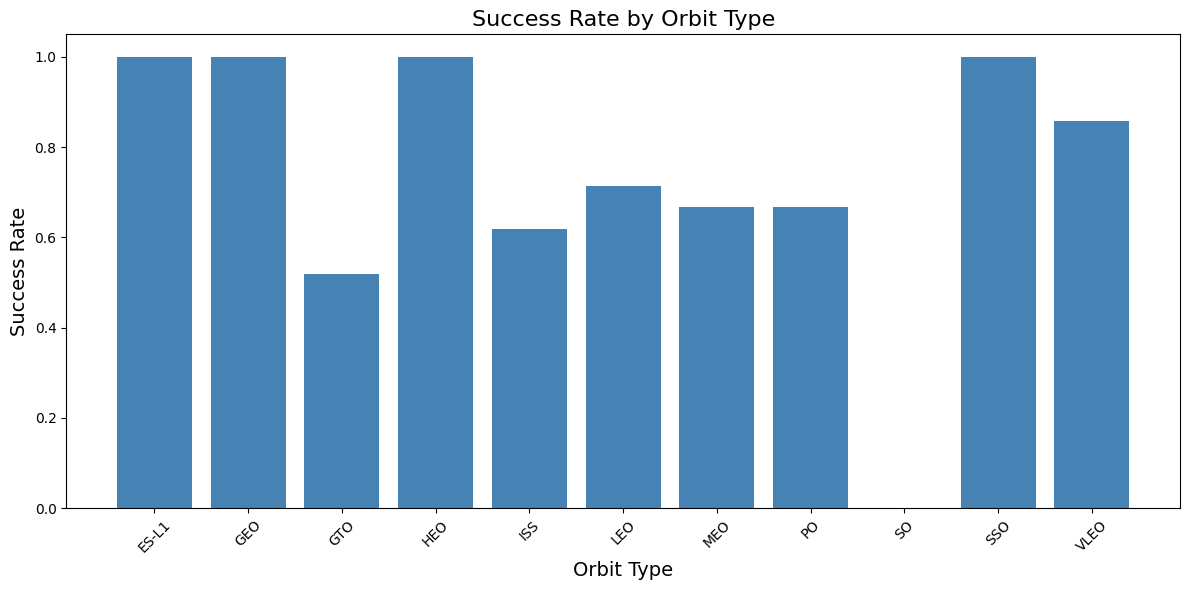

    Orbit  Success_Rate
0   ES-L1      1.000000
1     GEO      1.000000
2     GTO      0.518519
3     HEO      1.000000
4     ISS      0.619048
5     LEO      0.714286
6     MEO      0.666667
7      PO      0.666667
8      SO      0.000000
9     SSO      1.000000
10   VLEO      0.857143


In [7]:
# Bar chart of success rate per orbit
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
orbit_success.columns = ['Orbit', 'Success_Rate']

plt.figure(figsize=(12, 6))
plt.bar(orbit_success['Orbit'], orbit_success['Success_Rate'], color='steelblue')
plt.xlabel('Orbit Type', fontsize=14)
plt.ylabel('Success Rate', fontsize=14)
plt.title('Success Rate by Orbit Type', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(orbit_success)

### TASK 4: Visualize the relationship between FlightNumber and Orbit type


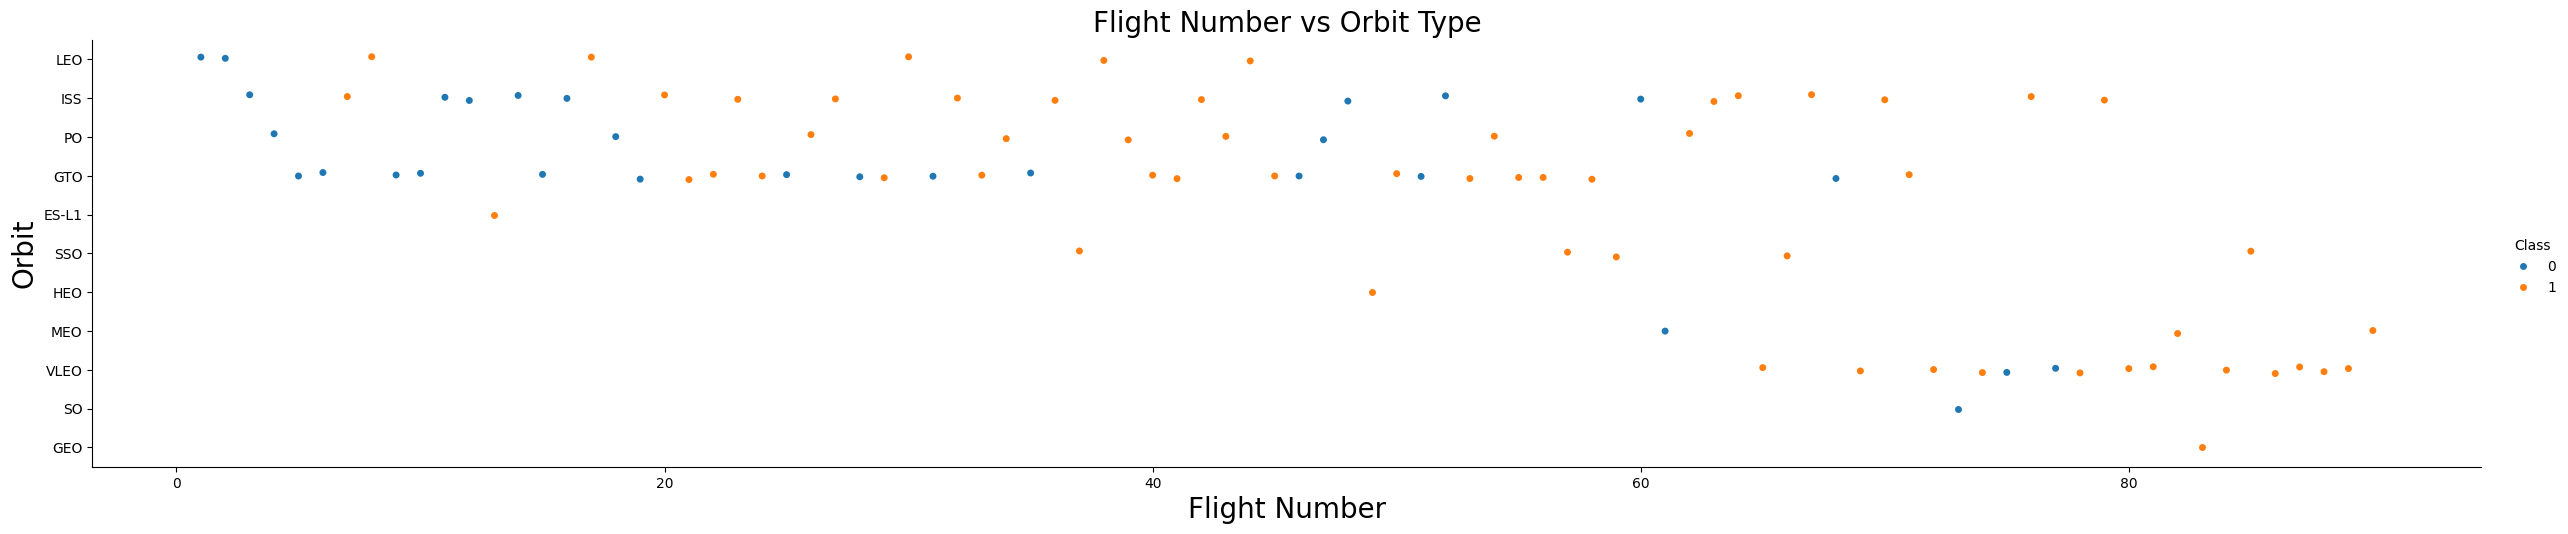

In [8]:
# Plot FlightNumber vs Orbit with hue = Class
sns.catplot(x="FlightNumber", y="Orbit", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit", fontsize=20)
plt.title("Flight Number vs Orbit Type", fontsize=20)
plt.show()

### TASK 5: Visualize the relationship between Payload and Orbit type


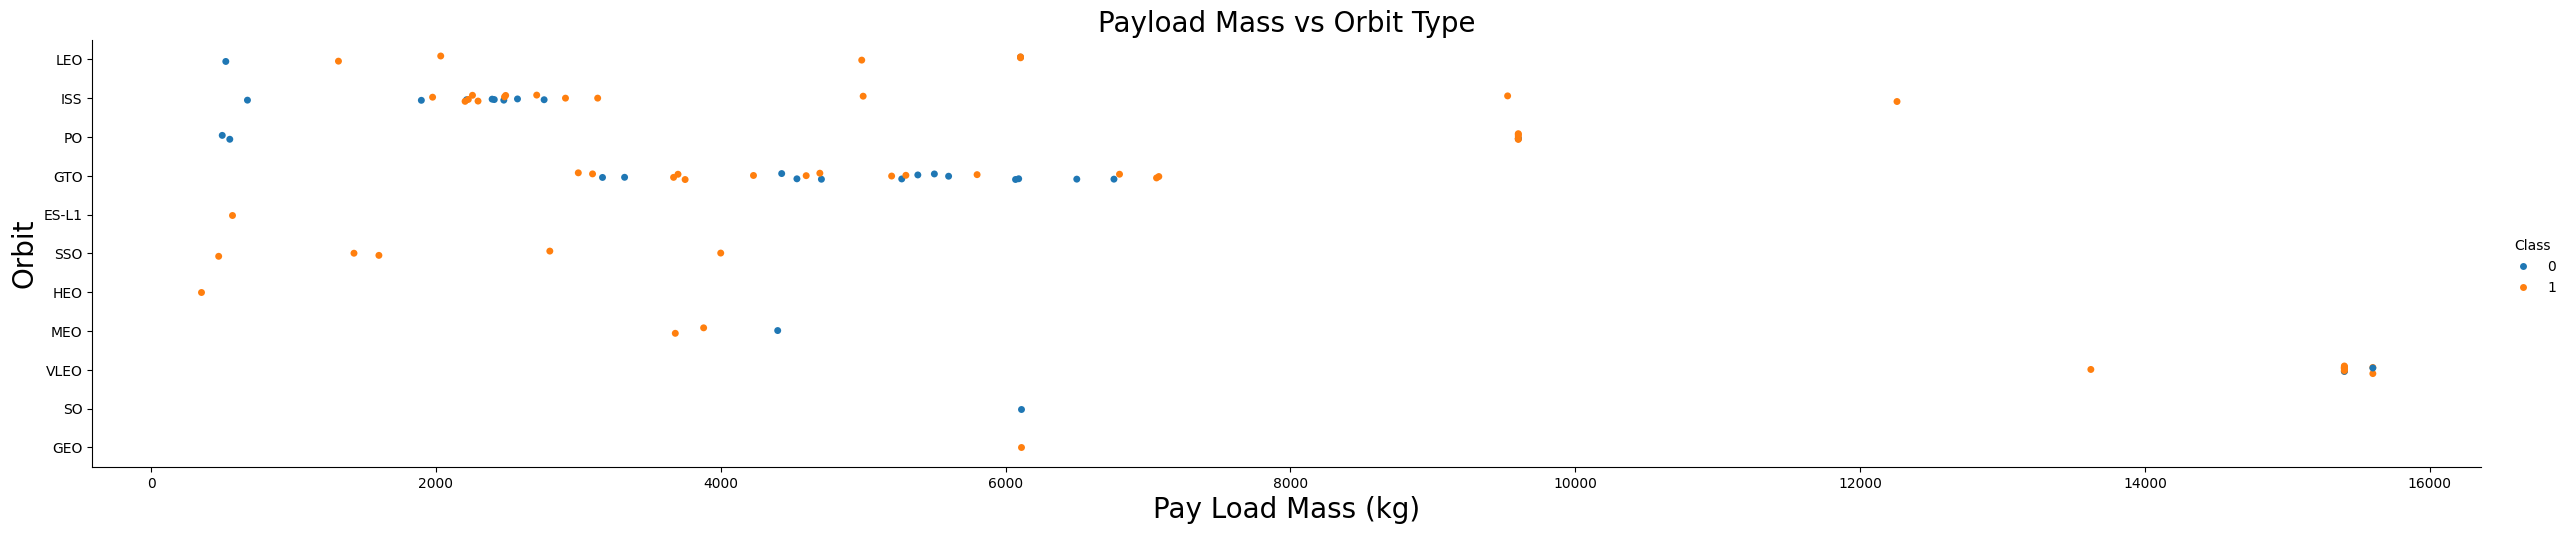

In [9]:
# Plot PayloadMass vs Orbit with hue = Class
sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=5)
plt.xlabel("Pay Load Mass (kg)", fontsize=20)
plt.ylabel("Orbit", fontsize=20)
plt.title("Payload Mass vs Orbit Type", fontsize=20)
plt.show()

### TASK 6: Visualize the launch success yearly trend


In [10]:
# Extract year from Date
year = []
def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year

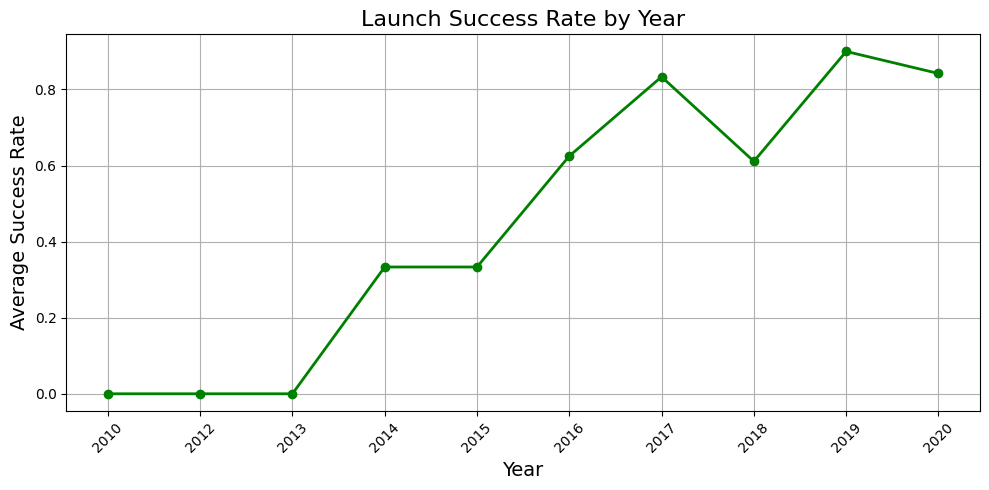

In [11]:
# Plot success rate per year
df['Year'] = df['Date'].apply(lambda x: x.split('-')[0])
yearly_success = df.groupby('Year')['Class'].mean().reset_index()
yearly_success.columns = ['Year', 'Success_Rate']

plt.figure(figsize=(10, 5))
plt.plot(yearly_success['Year'], yearly_success['Success_Rate'], marker='o', color='green', linewidth=2)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Success Rate', fontsize=14)
plt.title('Launch Success Rate by Year', fontsize=16)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Features Engineering


In [12]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins',
               'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK 7: Create dummy variables to categorical columns


In [13]:
# Apply OneHotEncoder using get_dummies on Orbit, LaunchSite, LandingPad, Serial
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK 8: Cast all numeric columns to `float64`


In [14]:
# Cast entire dataframe to float64
features_one_hot = features_one_hot.astype('float64')
features_one_hot.dtypes

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object

In [15]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print('dataset_part_3.csv exporté avec succès.')

dataset_part_3.csv exporté avec succès.


## Authors

<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a>

**Completed by:** [Hrestak33](https://github.com/Hrestak33)


Copyright © 2020 IBM Corporation. All rights reserved.
